# **Read Data**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/smart_parking_Data_28k.csv')
df.head(5)

,timestamp,event,user_id,status,reason,occupancy,hour,day,parking_duration,price,payment_method
0,2026-03-15 20:31:18.348450,entry,user_1424,success,success,0.02,20,Sunday,236.0,19.67,apple_pay
1,2026-03-15 20:32:18.348450,entry,user_132,success,success,0.04,20,Sunday,87.0,7.25,credit_card
2,2026-03-15 20:33:18.348450,entry,user_713,success,success,0.06,20,Sunday,22.0,1.83,credit_card
3,2026-03-15 20:34:18.348450,entry,user_670,success,success,0.08,20,Sunday,138.0,11.50,apple_pay
4,2026-03-15 20:36:18.348450,entry,user_238,success,success,0.10,20,Sunday,74.0,6.17,credit_card


In [4]:
df.tail(5)

,timestamp,event,user_id,status,reason,occupancy,hour,day,parking_duration,price,payment_method
28219,2026-05-07 02:45:18.348450,entry,user_1803,success,success,0.44,2,Thursday,235.0,19.58,credit_card
28220,2026-05-07 02:47:18.348450,entry,user_173,success,success,0.46,2,Thursday,215.0,17.92,credit_card
28221,2026-05-07 02:51:18.348450,entry,user_644,success,success,0.46,2,Thursday,110.0,9.17,google_pay
28222,2026-05-07 02:57:18.348450,entry,user_181,success,success,0.46,2,Thursday,96.0,8.00,google_pay
28223,2026-05-07 03:00:18.348450,entry,user_991,success,success,0.48,3,Thursday,205.0,17.08,credit_card


# EDA

In [5]:
df.sample(4)

,timestamp,event,user_id,status,reason,occupancy,hour,day,parking_duration,price,payment_method
11792,2026-04-06 18:47:18.348450,entry,user_641,denied,booking_expired,0.96,18,Monday,NaN,NaN,NaN
6865,2026-03-28 17:42:18.348450,entry,user_1106,success,success,0.78,17,Saturday,42.0,3.50,apple_pay
21287,2026-04-24 04:52:18.348450,entry,user_1220,success,success,0.58,4,Friday,137.0,11.42,google_pay
6125,2026-03-27 08:29:18.348450,entry,user_1859,success,success,0.50,8,Friday,67.0,5.58,credit_card


In [6]:
df.shape

(28224, 11)

In [7]:
df.columns

Index(['timestamp', 'event', 'user_id', 'status', 'reason', 'occupancy',
       'hour', 'day', 'parking_duration', 'price', 'payment_method'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28224 entries, 0 to 28223
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         28224 non-null  object 
 1   event             28224 non-null  object 
 2   user_id           28224 non-null  object 
 3   status            28224 non-null  object 
 4   reason            28224 non-null  object 
 5   occupancy         28224 non-null  float64
 6   hour              28224 non-null  int64  
 7   day               28224 non-null  object 
 8   parking_duration  21471 non-null  float64
 9   price             21471 non-null  float64
 10  payment_method    21471 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 2.4+ MB


In [9]:
df.isnull().sum()

,0
timestamp,0
event,0
user_id,0
status,0
reason,0
occupancy,0
hour,0
day,0
parking_duration,6753
price,6753


# Handling Missing Values

**Link the price to the duration**

In [42]:
df['price'] = df.groupby('parking_duration')['price'].transform(lambda x: x.fillna(x.median()))

**using the median according to the hour**

In [11]:
df['parking_duration'] = df.groupby('hour')['parking_duration'].transform(lambda x: x.fillna(x.median()))

In [12]:
df['payment_method'] = df['payment_method'].fillna(df['payment_method'].mode()[0])

In [44]:
df.isnull().sum()

,0
timestamp,0
event,0
user_id,0
status,0
reason,0
occupancy,0
hour,0
day,0
parking_duration,0
price,420


In [18]:
df.describe()

,occupancy,hour,parking_duration,price
count,28224.000000,28224.000000,28224.000000,27804.000000
mean,0.796922,13.105867,130.613060,10.886298
std,0.179169,6.862578,55.591353,4.667334
min,0.020000,0.000000,20.000000,1.670000
25%,0.640000,8.000000,93.000000,7.670000
50%,0.820000,14.000000,132.000000,11.000000
75%,0.980000,19.000000,168.000000,14.080000
max,1.000000,23.000000,240.000000,20.000000


In [19]:
df['day'].value_counts()

,count
day,
Monday,4310
Tuesday,4297
Wednesday,4250
Sunday,3943
Thursday,3821
Saturday,3816
Friday,3787


**The bar chart shows the busiest days.**

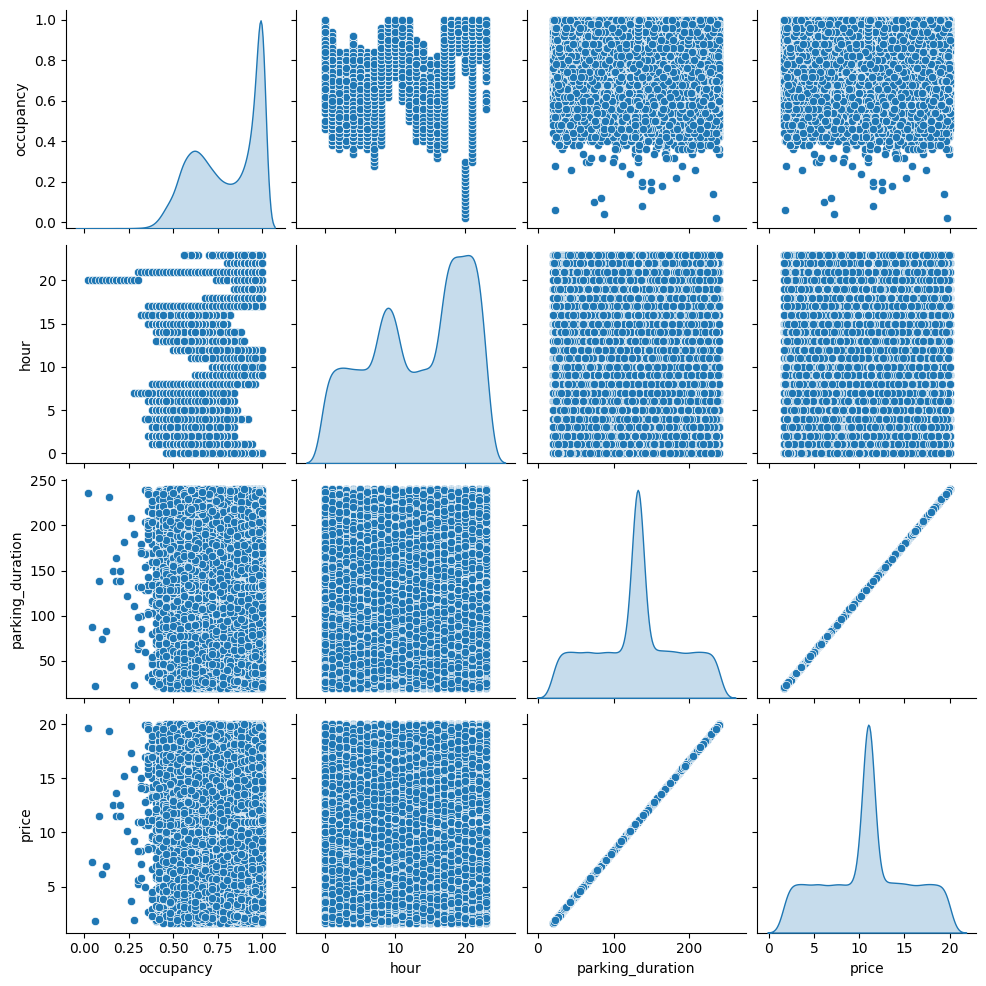

In [20]:
sns.pairplot(df, diag_kind='kde')
plt.show()

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

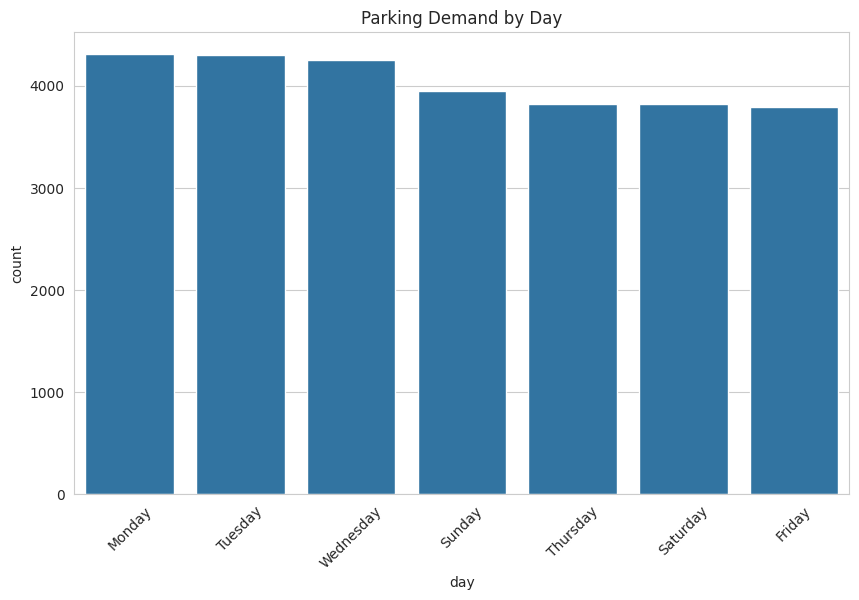

In [22]:
sns.countplot(x='day', data=df, order=df['day'].value_counts().index)
plt.title('Parking Demand by Day')
plt.xticks(rotation=45)
plt.show()

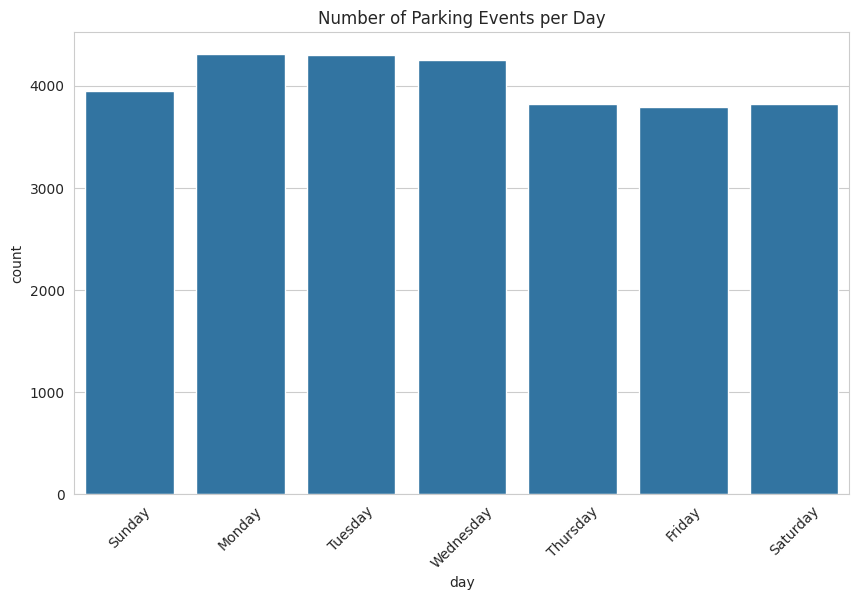

In [23]:
sns.countplot(x='day', data=df)
plt.title('Number of Parking Events per Day')
plt.xticks(rotation=45)
plt.show()

**Peak Hour Analysis**

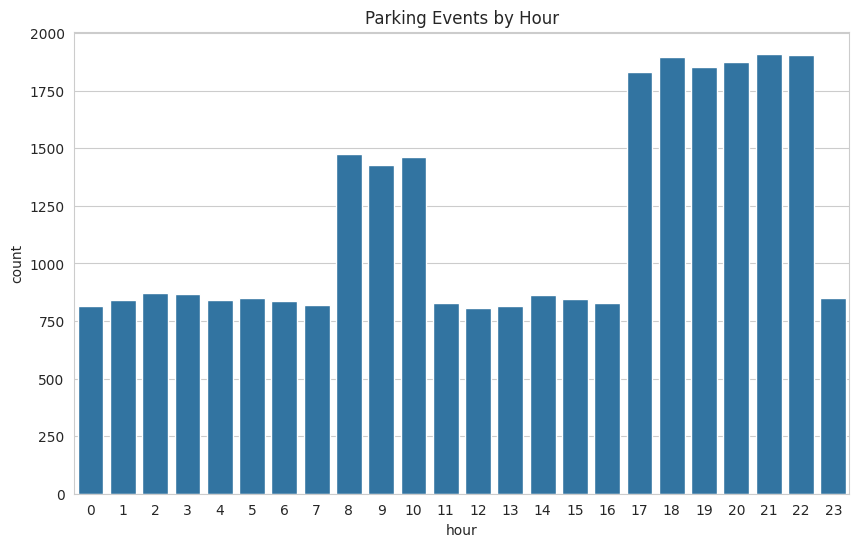

In [24]:
sns.countplot(x='hour', data=df)
plt.title('Parking Events by Hour')
plt.show()

**Occupancy Analysis**

**Parking Duration vs Price**

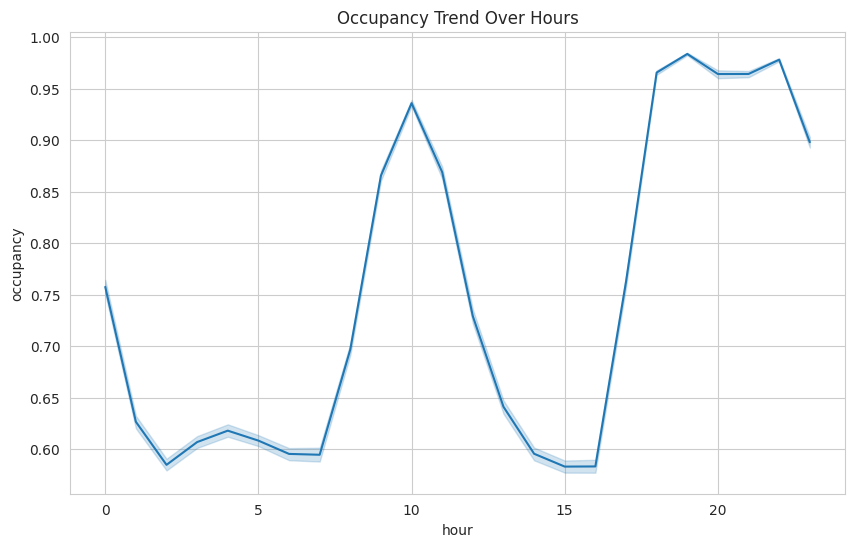

In [25]:
sns.lineplot(x='hour', y='occupancy', data=df)
plt.title('Occupancy Trend Over Hours')
plt.show()

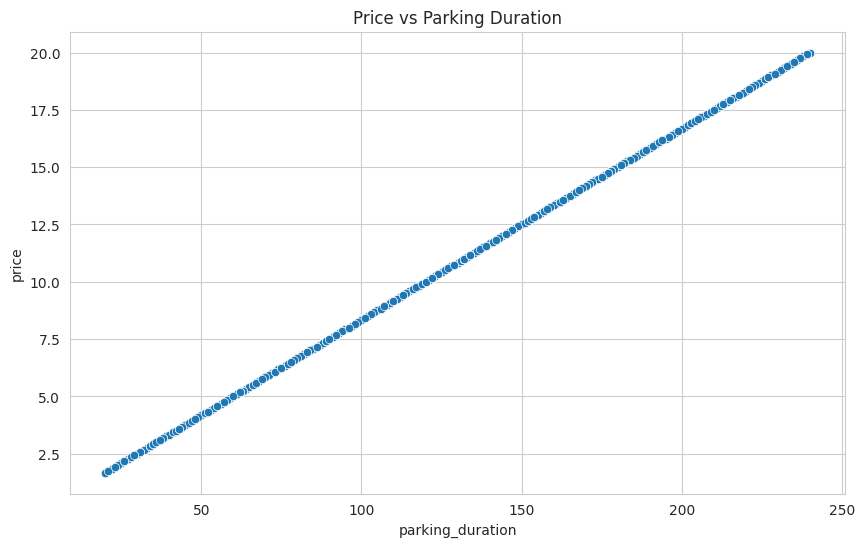

In [26]:
sns.scatterplot(x='parking_duration', y='price', data=df)
plt.title('Price vs Parking Duration')
plt.show()

**Payment Methods**

In [27]:
df['payment_method'].value_counts()

,count
payment_method,
apple_pay,14029
credit_card,7120
google_pay,7075


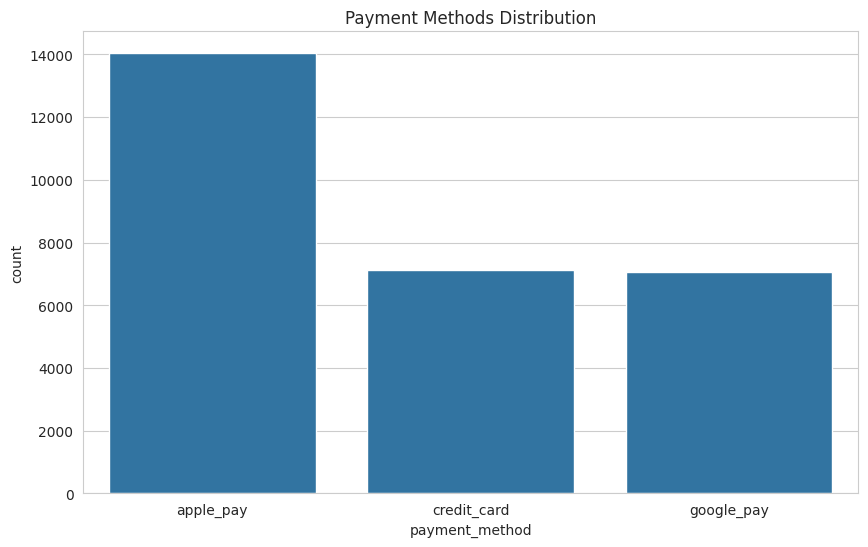

In [28]:
sns.countplot(x='payment_method', data=df)
plt.title('Payment Methods Distribution')
plt.show()

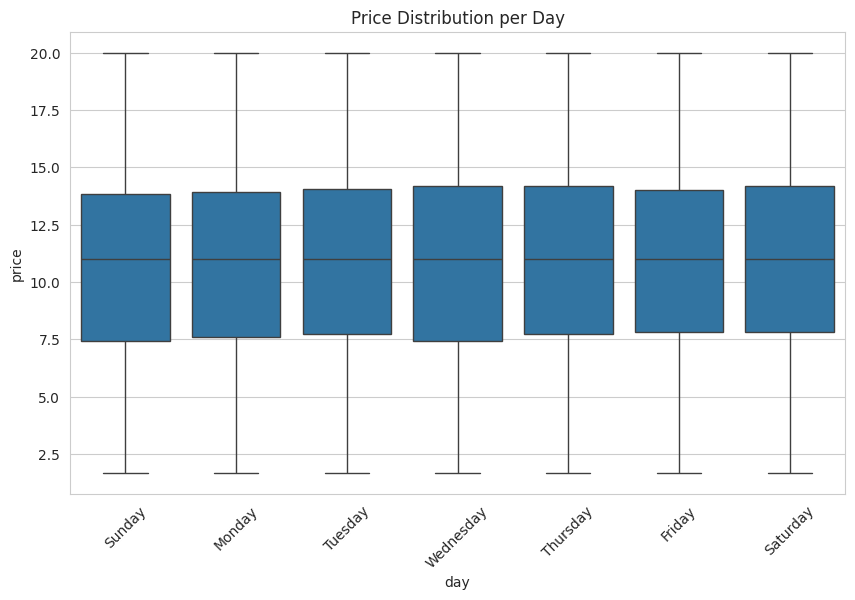

In [29]:
sns.boxplot(x='day', y='price', data=df)
plt.title('Price Distribution per Day')
plt.xticks(rotation=45)
plt.show()

**The price changes depending on the day and hour.**

/tmp/ipykernel_4871/782822143.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='hour', y='price', hue='day', data=subset, ci=None)


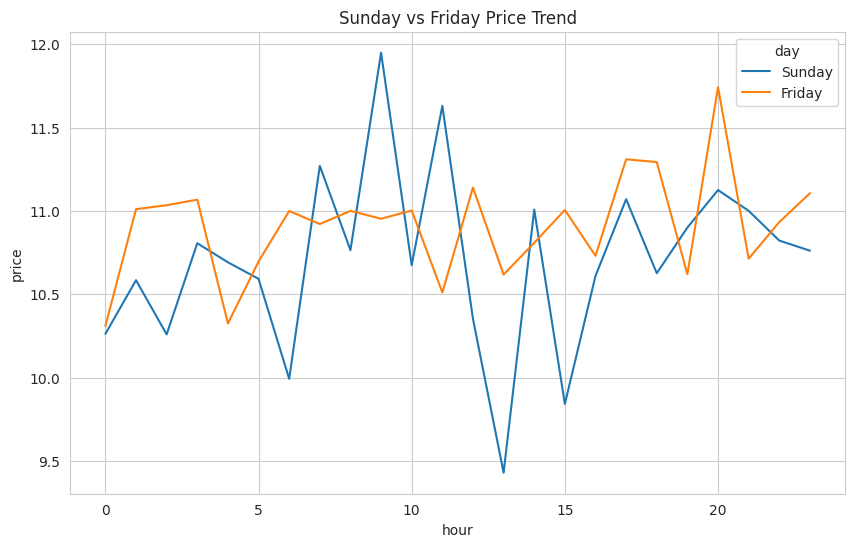

In [30]:
subset = df[df['day'].isin(['Sunday', 'Friday'])]
sns.lineplot(x='hour', y='price', hue='day', data=subset, ci=None)
plt.title('Sunday vs Friday Price Trend')
plt.show()

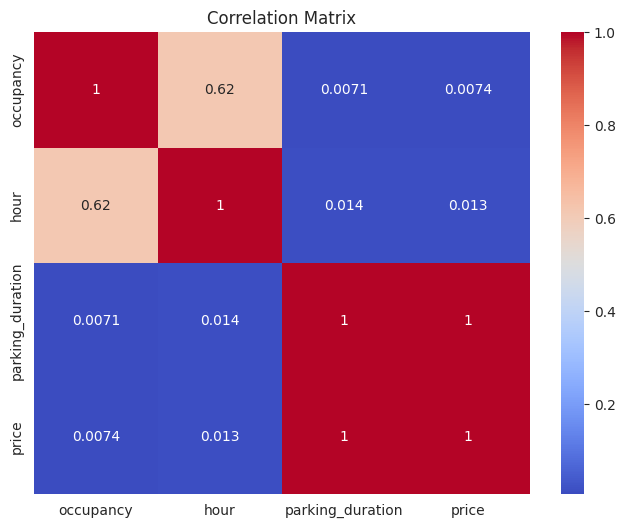

In [31]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Calculate Mean**

In [32]:
rec_df = df.groupby(['day', 'hour']).agg({
    'occupancy': 'mean',
    'price': 'mean'
}).reset_index()

In [33]:
rec_df['score'] = (1 - rec_df['occupancy']) * 0.7 + (1 / rec_df['price']) * 0.3

In [34]:
best_times = rec_df.sort_values(by='score', ascending=False)

best_times.head(10)

,day,hour,occupancy,price,score
50,Saturday,2,0.549748,10.648319,0.343350
63,Saturday,15,0.556260,10.334146,0.339648
146,Wednesday,2,0.554833,11.254583,0.338272
98,Thursday,2,0.558305,10.964576,0.336547
16,Friday,16,0.559630,10.731296,0.336215
64,Saturday,16,0.558136,11.539746,0.335302
112,Thursday,16,0.559029,11.363301,0.335080
127,Tuesday,7,0.561111,11.145000,0.334140
102,Thursday,6,0.567500,11.238173,0.329445
31,Monday,7,0.567544,11.294825,0.329280


In [35]:
def recommend_time(day):
    options = rec_df[rec_df['day'] == day]
    best = options.sort_values(by='score', ascending=False).iloc[0]

    return f"best day {day} hour {int(best['hour'])}:00 "

In [36]:
recommend_time('Sunday')

'best day Sunday hour 15:00 '

In [37]:
recommend_time('Monday')

'best day Monday hour 7:00 '

In [38]:
recommend_time('Friday')

'best day Friday hour 16:00 '

In [39]:
def recommend(day, hour=None, prefer='balanced'):

    data = rec_df[rec_df['day'] == day]

    if prefer == 'cheap':
        best = data.sort_values(by='price').iloc[0]

    elif prefer == 'less crowded':
        best = data.sort_values(by='occupancy').iloc[0]

    else:
        best = data.sort_values(by='score', ascending=False).iloc[0]

    return best